# Telecom Customer Churn Analysis
## CIDM 6312 Final Project
## Alexis Lopez

In [1]:
import pandas as pd

df = pd.read_csv('/content/telecom_churn.csv')

df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


## Visualization 1: Overall Customer Churn Distribution
This chart shows the number of customers who churned versus those who were retained.

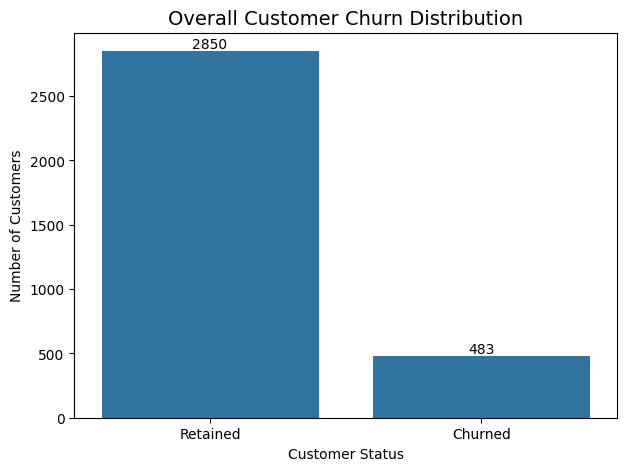

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create readable labels
df['Churn_Label'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})

# Count values
churn_counts = df['Churn_Label'].value_counts()

# Plot
plt.figure(figsize=(7,5))
sns.barplot(x=churn_counts.index, y=churn_counts.values)

# Titles and labels
plt.title('Overall Customer Churn Distribution', fontsize=14)
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

# Add data labels
for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 20, str(value), ha='center')

plt.show()

This chart shows the overall distribution of customer churn within the dataset. The majority of customers are retained (2,850), while a smaller portion (483) have churned. Although retention is higher, the number of churned customers is still significant, indicating a clear opportunity for the company to improve customer retention strategies. This visualization sets the foundation for further analysis into what factors are contributing to churn.

## Visualization 2: Churn Rate by Contract Renewal Status  
This chart compares churn rates between customers who renewed their contracts and those who did not. It helps identify the impact of contract commitment on customer retention.

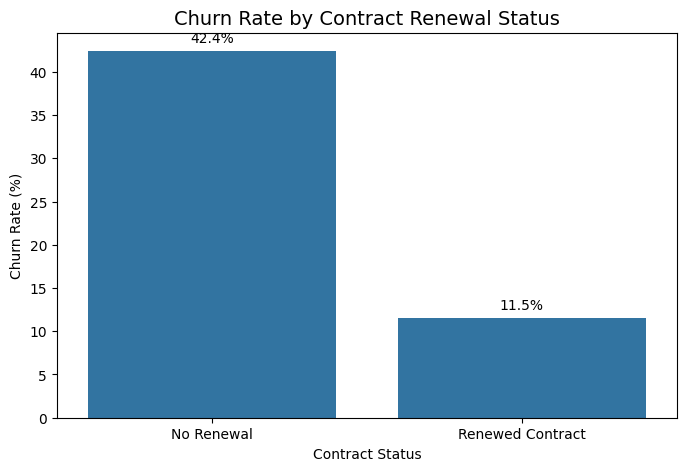

In [3]:
# Create readable contract labels
df['Contract_Label'] = df['ContractRenewal'].map({
    0: 'No Renewal',
    1: 'Renewed Contract'
})

# Calculate churn rate
contract_churn = df.groupby('Contract_Label')['Churn'].mean().reset_index()
contract_churn['Churn_Rate'] = contract_churn['Churn'] * 100

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=contract_churn, x='Contract_Label', y='Churn_Rate')

# Labels
plt.title('Churn Rate by Contract Renewal Status', fontsize=14)
plt.xlabel('Contract Status')
plt.ylabel('Churn Rate (%)')

# Data labels
for i, value in enumerate(contract_churn['Churn_Rate']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.show()

This chart compares churn rates between customers who renewed their contracts and those who did not. Customers without contract renewal have a significantly higher churn rate (42.4%) compared to those with renewed contracts (11.5%). This indicates that contract commitment is a key factor in customer retention. Encouraging customers to renew or commit to longer-term contracts could substantially reduce churn and improve overall customer stability.

## Visualization 3: Monthly Charges by Customer Churn Status  
This visualization compares the distribution of monthly charges between customers who churned and those who were retained. It highlights how pricing may influence customer decisions.

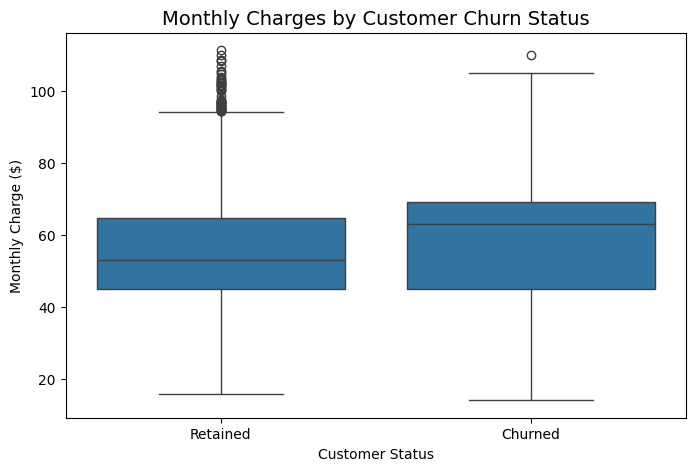

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn_Label', y='MonthlyCharge')

plt.title('Monthly Charges by Customer Churn Status', fontsize=14)
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charge ($)')

plt.show()

This visualization compares the distribution of monthly charges between customers who churned and those who were retained. Customers who churned generally have higher monthly charges, as shown by the higher median and overall distribution. This suggests that pricing may be a key factor influencing customer decisions to leave. Customers paying higher monthly fees may perceive less value or be more sensitive to cost, indicating an opportunity for the company to implement pricing adjustments, discounts, or targeted retention offers.

## Visualization 4: Churn Rate by Number of Customer Service Calls  
This chart shows how churn rate changes based on the number of customer service calls. It helps identify whether customer service interactions are linked to customer dissatisfaction.

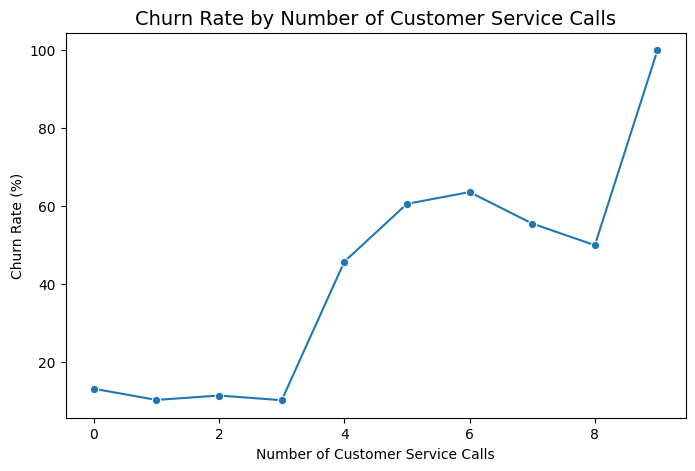

In [5]:
# Churn rate by number of customer service calls
service_churn = df.groupby('CustServCalls')['Churn'].mean().reset_index()
service_churn['Churn_Rate'] = service_churn['Churn'] * 100

plt.figure(figsize=(8,5))
sns.lineplot(data=service_churn, x='CustServCalls', y='Churn_Rate', marker='o')

plt.title('Churn Rate by Number of Customer Service Calls', fontsize=14)
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Churn Rate (%)')

plt.show()

This visualization illustrates the relationship between the number of customer service calls and churn rate. Customers who make few service calls have relatively low churn rates; however, once the number of calls exceeds three, the churn rate increases sharply. This suggests that frequent customer service interactions may indicate unresolved issues or dissatisfaction. As a result, improving service quality and resolving customer concerns more efficiently could significantly reduce churn among high-risk customers.

## Visualization 5: High-Risk Customer Segment Analysis  
This annotated visualization highlights a high-risk customer group based on contract status, service usage, and monthly charges. It identifies the customers most likely to churn and supports targeted business recommendations.

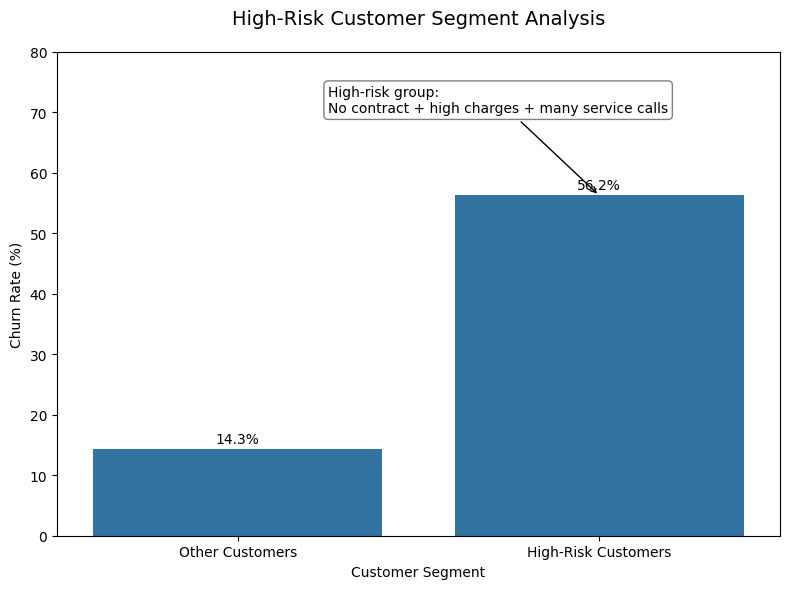

In [11]:
# Create high-risk group
df['High_Risk'] = (
    (df['ContractRenewal'] == 0) &
    (df['CustServCalls'] >= 4) &
    (df['MonthlyCharge'] > df['MonthlyCharge'].median())
)

# Calculate churn rates
risk_churn = df.groupby('High_Risk')['Churn'].mean().reset_index()
risk_churn['Segment'] = risk_churn['High_Risk'].map({
    False: 'Other Customers',
    True: 'High-Risk Customers'
})
risk_churn['Churn_Rate'] = risk_churn['Churn'] * 100

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=risk_churn, x='Segment', y='Churn_Rate')

plt.title('High-Risk Customer Segment Analysis', fontsize=14, pad=20)
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')

# Add labels on bars
for i, value in enumerate(risk_churn['Churn_Rate']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

# Add space at the top
plt.ylim(0, 80)

# Get high-risk value
high_risk_value = risk_churn.loc[risk_churn['High_Risk'] == True, 'Churn_Rate'].values[0]

# Annotation (FINAL FIXED POSITION)
plt.annotate(
    'High-risk group:\nNo contract + high charges + many service calls',
    xy=(1, high_risk_value),
    xytext=(0.25, 70),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray")
)

plt.tight_layout()
plt.show()

This annotated visualization highlights a high-risk customer segment defined by customers who do not renew contracts, have higher monthly charges, and make frequent customer service calls. This group exhibits a significantly higher churn rate (56.2%) compared to other customers (14.3%), demonstrating that these combined factors strongly contribute to customer attrition. By identifying this segment, the company can focus retention efforts on the most vulnerable customers through targeted incentives, improved service quality, and proactive engagement strategies.